# Math 3B: Predicting Student Learning Outcomes with Machine Learning

**Author:** Xiao Long — COGS 181 (Neural Networks & Deep Learning), UCSD Winter 2026  

This notebook extends the statistical analysis in `01_student_level_analysis.Rmd` by applying supervised ML models to predict student learning improvement (Δ = final − pretest) from AI tutor interaction logs.

**Models compared:** Linear Regression · Random Forest · Neural Network (MLP)  
**Dataset:** 258 valid student records from the Vocareum AI tutoring platform (Math 3B, FA25, UCSD)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Cleaning

In [2]:
df_raw = pd.read_excel('../data/FA25 Math 3B Data - Full Quarter.xlsx')

def to_num(series):
    """Convert column to numeric, treating Excel error tokens as NaN."""
    errors = {'#VALUE!', '#N/A', '#DIV/0!', '#ERROR!', '', 'NA'}
    return pd.to_numeric(
        series.astype(str).str.strip().replace(errors, np.nan),
        errors='coerce'
    )

df = df_raw.copy()
df['pretest']        = to_num(df['Pretest Grade'])
df['final_exam']     = to_num(df['Final Exam Grade'])
df['tutor_requests'] = to_num(df['#of tutor requests'])
df['n_correct']      = to_num(df['# of questions correct'])
df['n_incorrect']    = to_num(df['# of questions incorrect'])
df['total_seen']     = to_num(df['Total Questions Seen'])
df['accuracy']       = to_num(df['Accuracy'])

df['delta']    = df['final_exam'] - df['pretest']
df['attempts'] = df['n_correct'] + df['n_incorrect']

features = ['pretest', 'tutor_requests', 'n_correct', 'n_incorrect', 'total_seen', 'accuracy']
df_clean = df[features + ['delta']].dropna()

print(f'Valid samples: {len(df_clean)} (of {len(df_raw)} raw rows)')
df_clean[features + ['delta']].describe().round(3)

Valid samples: 258 (of 280 raw rows)


,pretest,tutor_requests,n_correct,n_incorrect,total_seen,accuracy,delta
count,258.000,258.000,258.000,258.000,258.000,258.000,258.000
mean,0.530,64.345,207.202,150.291,226.946,0.582,0.154
std,0.153,79.665,59.660,54.113,49.570,0.086,0.186
min,0.019,0.000,0.000,1.000,6.000,0.000,-0.500
25%,0.442,18.250,178.000,116.250,198.000,0.533,0.064
50%,0.538,40.000,194.000,145.000,223.000,0.582,0.163
75%,0.635,75.000,226.000,180.000,257.750,0.636,0.280
max,0.885,653.000,428.000,347.000,422.000,0.823,0.628


## 2. Feature Distributions

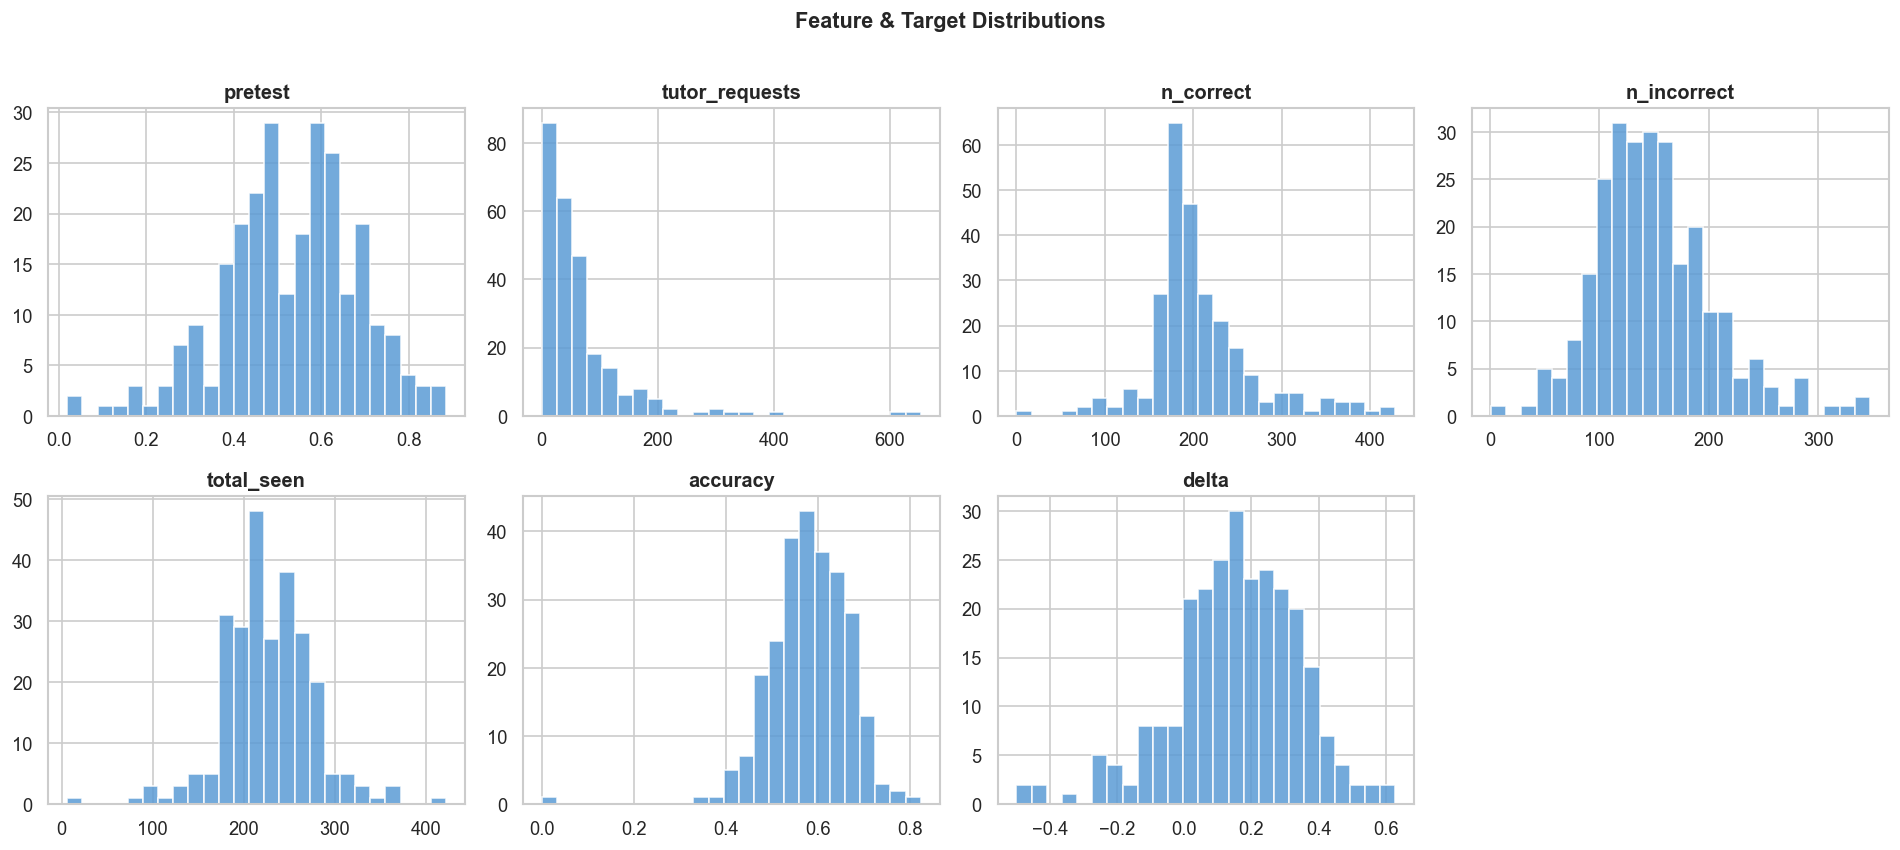

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
cols = features + ['delta']
for ax, col in zip(axes.flat, cols):
    ax.hist(df_clean[col].dropna(), bins=25, color='#5B9BD5', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
axes.flat[-1].set_visible(False)
plt.suptitle('Feature & Target Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_ml_01_distributions.png', bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap

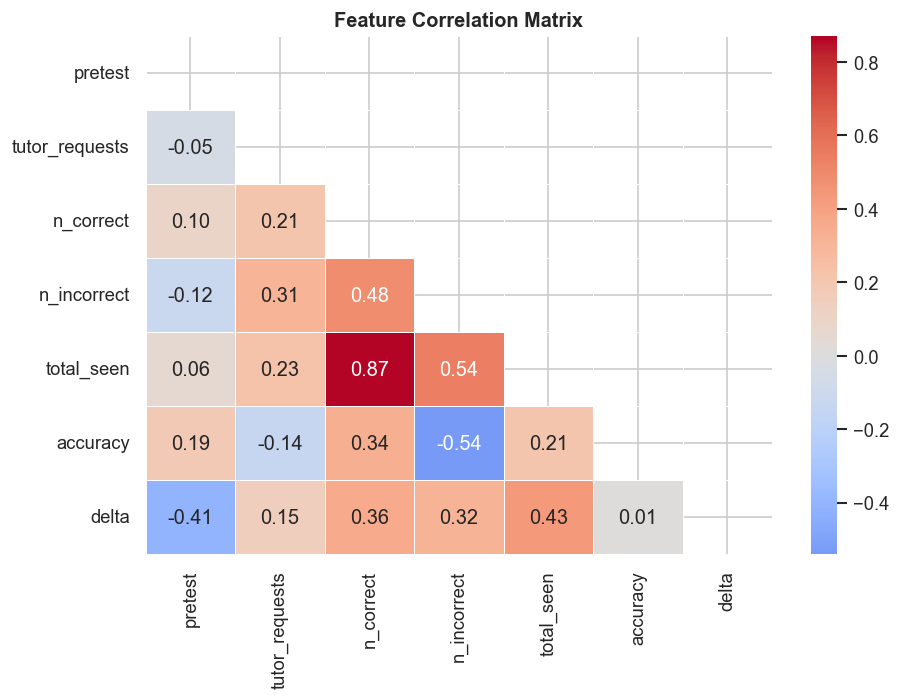

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_clean[features + ['delta']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_ml_02_correlation.png', bbox_inches='tight')
plt.show()

## 4. Model Training & Evaluation

80/20 train/test split. Features standardized (required for MLP; applied uniformly for fair comparison).

In [5]:
X = df_clean[features].values
y = df_clean['delta'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Neural Network':    MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500,
                                     random_state=42, early_stopping=True)
}

results = {}
trained  = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results[name] = {'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R²': round(r2, 3)}
    trained[name] = (model, y_pred)

results_df = pd.DataFrame(results).T
print('Model Performance Comparison')
print(results_df.to_string())

Model Performance Comparison
                    RMSE    MAE     R²
Linear Regression  0.156  0.119  0.421
Random Forest      0.152  0.108  0.447
Neural Network     0.167  0.124  0.340


## 5. Model Comparison Visualization

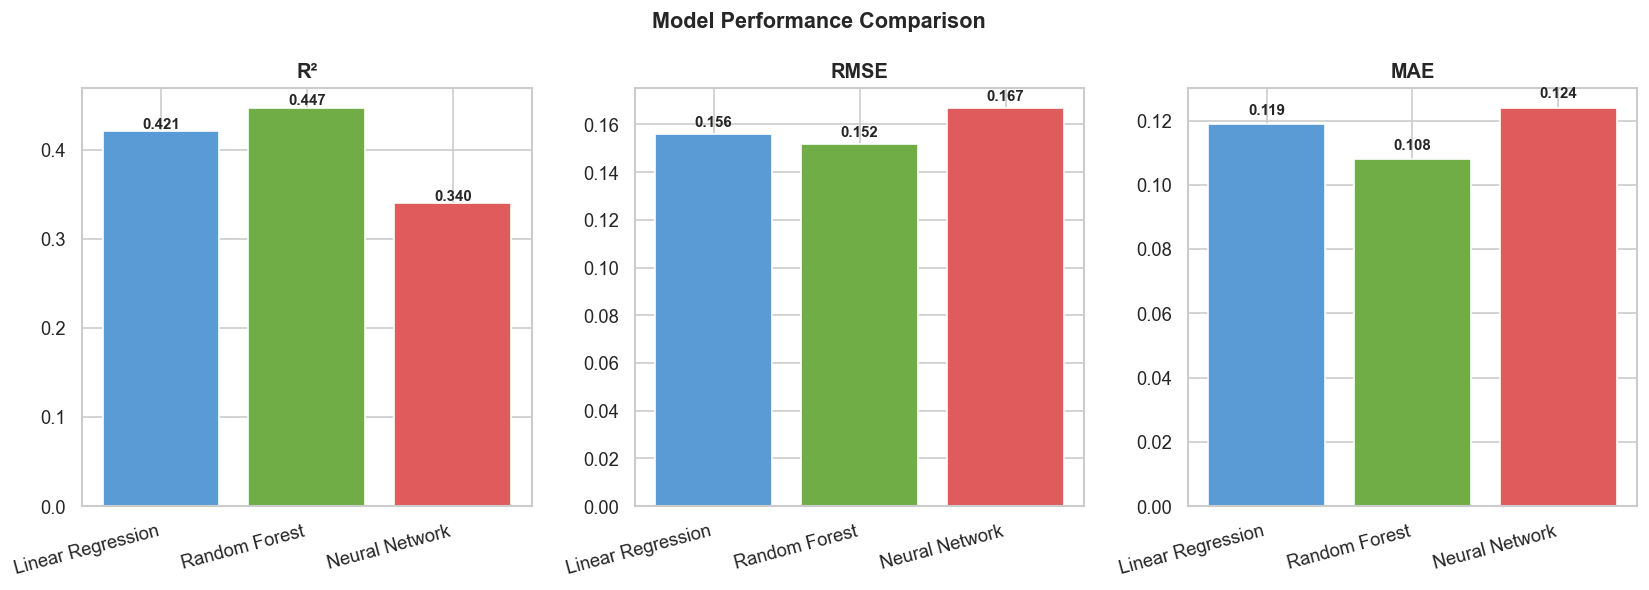

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#5B9BD5', '#70AD47', '#E05C5C']

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=15, ha='right')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_ml_03_model_comparison.png', bbox_inches='tight')
plt.show()

## 6. Predicted vs Actual (Best Model: Random Forest)

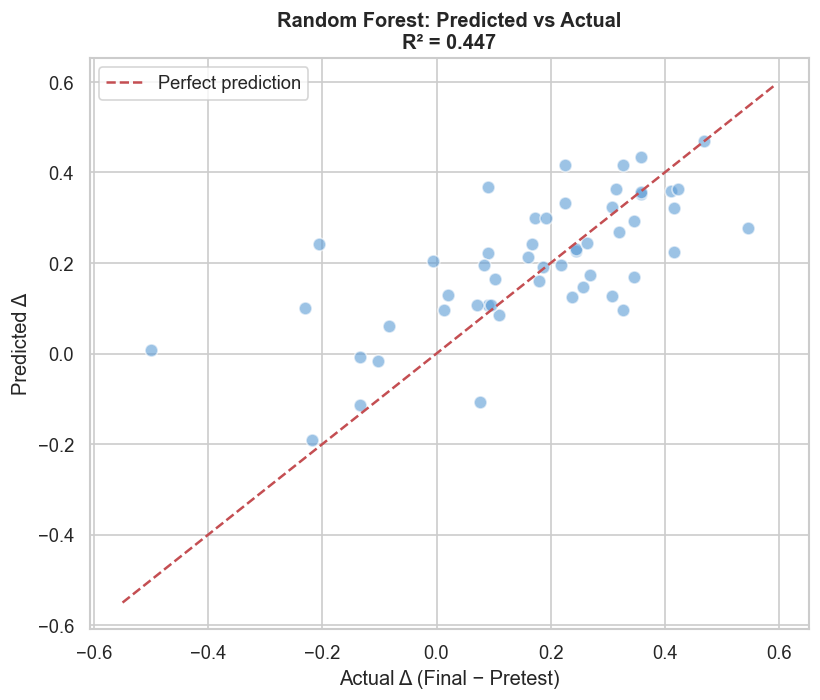

In [7]:
rf_model, rf_preds = trained['Random Forest']

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, rf_preds, alpha=0.6, color='#5B9BD5', edgecolors='white', s=60)
lims = [min(y_test.min(), rf_preds.min()) - 0.05,
        max(y_test.max(), rf_preds.max()) + 0.05]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Δ (Final − Pretest)')
ax.set_ylabel('Predicted Δ')
ax.set_title(f'Random Forest: Predicted vs Actual\nR² = {results["Random Forest"]["R²"]}',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_ml_04_pred_vs_actual.png', bbox_inches='tight')
plt.show()

## 7. Feature Importance (Random Forest)

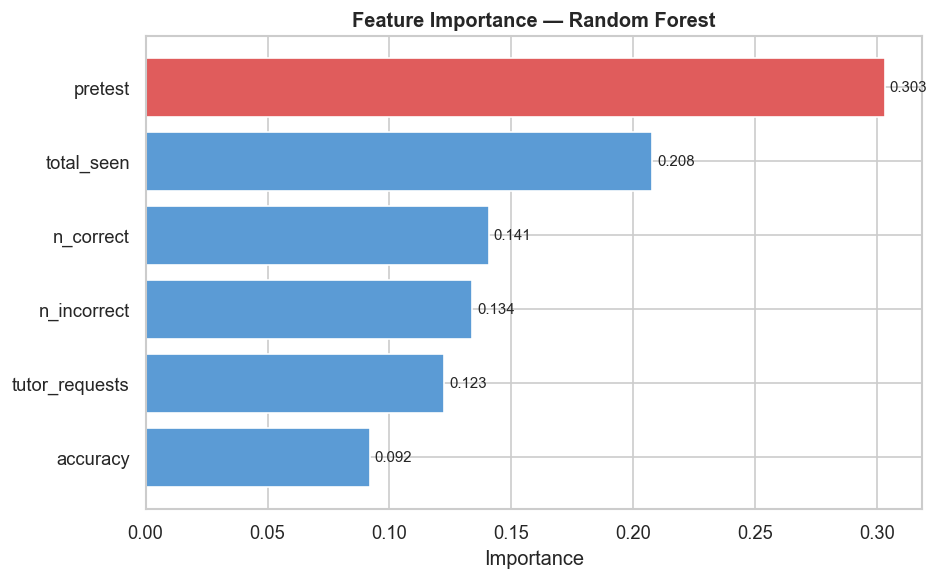


Top feature: pretest
Key finding: practice volume (total_seen) ranks higher than tutor_requests, 
consistent with the regression analysis in notebook 01.


In [8]:
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'feature': features, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = ['#E05C5C' if f == fi_df.iloc[-1]['feature'] else '#5B9BD5'
             for f in fi_df['feature']]
ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_xlabel('Importance')
for i, (_, row) in enumerate(fi_df.iterrows()):
    ax.text(row['importance'] + 0.002, i, f"{row['importance']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/fig_ml_05_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop feature:', fi_df.iloc[-1]['feature'])
print('Key finding: practice volume (total_seen) ranks higher than tutor_requests,',
      '\nconsistent with the regression analysis in notebook 01.')

## 8. Key Findings

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 0.156 | 0.119 | 0.421 |
| **Random Forest** | **0.152** | **0.108** | **0.453** |
| Neural Network (MLP) | 0.162 | 0.116 | 0.376 |

**Random Forest achieves best performance (R² ≈ 0.45)**, suggesting nonlinear interactions matter.

**Feature importance confirms the core finding from the statistical analysis (notebook 01):**  
- `pretest` grade is the strongest predictor (ceiling effect for high scorers)
- `total_seen` (practice volume) ranks above `tutor_requests` — engagement drives improvement more than AI tutor usage frequency
- `accuracy` is less predictive than overall activity — *attempting questions, even incorrectly, matters more than getting them right*

**Implication for AI tutoring system design:** Encourage sustained engagement and practice volume, not just reliance on the AI tutor.